# Blinkit Sales Analytics Project

## Tools Used
- MySQL
- Python
- Pandas
- NumPy
- Matplotlib

## Objective
Analyze Blinkit sales data to identify sales trends, outlet performance, product performance, and generate business insights using SQL and Python.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mysql.connector

In [2]:
connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password="2704",
    database="blinkit_project"
)

print("Connected Successfully!")

Connected Successfully!


In [3]:
query = "SELECT * FROM blinkit_sales"

df = pd.read_sql(query, connection)

df.head()

C:\Users\Samiksha\AppData\Local\Temp\ipykernel_18352\3973552003.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


,item_fat_content,item_identifier,item_type,outlet_establishment_year,outlet_identifier,outlet_location_type,outlet_size,outlet_type,item_visibility,item_weight,sales,rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.1,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.8,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2016,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2014,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.6,55.1614,5.0


In [4]:
df.shape

(8523, 12)

In [5]:
df.columns

Index(['item_fat_content', 'item_identifier', 'item_type',
       'outlet_establishment_year', 'outlet_identifier',
       'outlet_location_type', 'outlet_size', 'outlet_type', 'item_visibility',
       'item_weight', 'sales', 'rating'],
      dtype='str')

In [6]:
df.dtypes

item_fat_content                 str
item_identifier                  str
item_type                        str
outlet_establishment_year      int64
outlet_identifier                str
outlet_location_type             str
outlet_size                      str
outlet_type                      str
item_visibility              float64
item_weight                      str
sales                        float64
rating                       float64
dtype: object

In [7]:
df.isnull().sum()

item_fat_content             0
item_identifier              0
item_type                    0
outlet_establishment_year    0
outlet_identifier            0
outlet_location_type         0
outlet_size                  0
outlet_type                  0
item_visibility              0
item_weight                  0
sales                        0
rating                       0
dtype: int64

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   item_fat_content           8523 non-null   str    
 1   item_identifier            8523 non-null   str    
 2   item_type                  8523 non-null   str    
 3   outlet_establishment_year  8523 non-null   int64  
 4   outlet_identifier          8523 non-null   str    
 5   outlet_location_type       8523 non-null   str    
 6   outlet_size                8523 non-null   str    
 7   outlet_type                8523 non-null   str    
 8   item_visibility            8523 non-null   float64
 9   item_weight                8523 non-null   str    
 10  sales                      8523 non-null   float64
 11  rating                     8523 non-null   float64
dtypes: float64(3), int64(1), str(8)
memory usage: 799.2 KB


In [10]:
df.describe()

,outlet_establishment_year,item_visibility,sales,rating
count,8523.000000,8523.000000,8523.000000,8523.000000
mean,2016.450546,0.066132,140.992783,3.965857
std,3.189396,0.051598,62.275067,0.605651
min,2011.000000,0.000000,31.290000,1.000000
25%,2014.000000,0.026989,93.826500,4.000000
50%,2016.000000,0.053931,143.012800,4.000000
75%,2018.000000,0.094585,185.643700,4.200000
max,2022.000000,0.328391,266.888400,5.000000


In [11]:
df.head(10)

,item_fat_content,item_identifier,item_type,outlet_establishment_year,outlet_identifier,outlet_location_type,outlet_size,outlet_type,item_visibility,item_weight,sales,rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.1,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.8,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2016,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2014,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.6,55.1614,5.0
5,low fat,FDS52,Frozen Foods,2020,OUT017,Tier 2,Small,Supermarket Type1,0.005505,8.89,102.4016,5.0
6,Low Fat,NCU05,Health and Hygiene,2011,OUT010,Tier 3,Small,Grocery Store,0.098312,11.8,81.4618,5.0
7,Low Fat,NCD30,Household,2015,OUT045,Tier 2,Small,Supermarket Type1,0.026904,19.7,96.0726,5.0
8,Low Fat,FDW20,Fruits and Vegetables,2014,OUT013,Tier 3,High,Supermarket Type1,0.024129,20.75,124.1730,5.0
9,Low Fat,FDX25,Canned,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.101562,,181.9292,5.0


In [12]:
df.tail(10)

,item_fat_content,item_identifier,item_type,outlet_establishment_year,outlet_identifier,outlet_location_type,outlet_size,outlet_type,item_visibility,item_weight,sales,rating
8513,Regular,DRY23,Soft Drinks,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.108568,,42.9112,4.0
8514,low fat,FDA11,Baking Goods,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.043029,,94.7436,4.0
8515,low fat,FDK38,Canned,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.053032,,149.1734,4.0
8516,low fat,FDO38,Canned,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.072486,,78.9986,4.0
8517,low fat,FDG32,Fruits and Vegetables,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.175143,,222.3772,4.0
8518,low fat,NCT53,Health and Hygiene,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,,164.5526,4.0
8519,low fat,FDN09,Snack Foods,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.034706,,241.6828,4.0
8520,low fat,DRE13,Soft Drinks,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.027571,,86.6198,4.0
8521,reg,FDT50,Dairy,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.107715,,97.8752,4.0
8522,reg,FDM58,Snack Foods,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,,112.2544,4.0


In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.nunique()

item_fat_content                5
item_identifier              1559
item_type                      16
outlet_establishment_year       9
outlet_identifier              10
outlet_location_type            3
outlet_size                     3
outlet_type                     4
item_visibility              7668
item_weight                   416
sales                        5938
rating                         39
dtype: int64

In [16]:
df.memory_usage(deep=True)

Index                           132
item_fat_content             475240
item_identifier              460242
item_type                    514432
outlet_establishment_year     68184
outlet_identifier            468765
outlet_location_type         468765
outlet_size                  462120
outlet_type                  558186
item_visibility               68184
item_weight                  447427
sales                         68184
rating                        68184
dtype: int64

In [17]:
df.sample(5)

,item_fat_content,item_identifier,item_type,outlet_establishment_year,outlet_identifier,outlet_location_type,outlet_size,outlet_type,item_visibility,item_weight,sales,rating
2258,Low Fat,NCQ38,Others,2015,OUT045,Tier 2,Small,Supermarket Type1,0.013394,16.35,106.0280,4.2
5255,Regular,FDI60,Baking Goods,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.038381,7.22,62.3510,3.0
4525,Low Fat,FDV09,Snack Foods,2011,OUT010,Tier 3,High,Grocery Store,0.034428,12.1,146.6734,3.7
5747,Low Fat,FDZ44,Fruits and Vegetables,2018,OUT019,Tier 1,Small,Grocery Store,0.067810,,118.1808,1.0
741,Regular,FDT19,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.145266,7.59,172.9080,4.5


In [18]:
## Data Cleaning

In [19]:
(df == '').sum()

item_fat_content                0
item_identifier                 0
item_type                       0
outlet_establishment_year       0
outlet_identifier               0
outlet_location_type            0
outlet_size                     0
outlet_type                     0
item_visibility                 0
item_weight                  1463
sales                           0
rating                          0
dtype: int64

In [20]:
df['item_weight'].dtype

<StringDtype(storage='python', na_value=nan)>

In [21]:
import numpy as np

df['item_weight'] = df['item_weight'].replace('', np.nan)

In [22]:
df['item_weight'] = pd.to_numeric(df['item_weight'])

In [32]:
df['item_weight'].isnull().sum()

np.int64(0)

In [24]:
df['item_weight'] = df['item_weight'].fillna(df['item_weight'].mean())

In [25]:
df['item_weight'].isnull().sum()

np.int64(0)

In [26]:
df['item_weight'].dtype

dtype('float64')

In [27]:
df.to_csv("Dataset/blinkit_cleaned.csv", index=False)

In [28]:
## Exploratory Data Analysis (EDA)

In [29]:
df['sales'].sum()

np.float64(1201681.4928000001)

In [30]:
df['sales'].mean()

np.float64(140.99278338613166)

In [31]:
df['sales'].max()

np.float64(266.8884)

In [33]:
df['sales'].min()

np.float64(31.29)

In [34]:
df['rating'].mean()

np.float64(3.965857092573038)

In [35]:
df.groupby('item_type')['sales'].sum().sort_values(ascending=False)

item_type
Fruits and Vegetables    178124.0810
Snack Foods              175433.9224
Household                135976.5254
Frozen Foods             118558.8814
Dairy                    101276.4616
Canned                    90706.7290
Baking Goods              81894.7364
Health and Hygiene        68025.8388
Meat                      59449.8638
Soft Drinks               58514.1670
Breads                    35379.1198
Hard Drinks               29334.6806
Others                    22451.8916
Starchy Foods             21880.0274
Breakfast                 15596.6966
Seafood                    9077.8700
Name: sales, dtype: float64

In [36]:
df.groupby('item_type')['sales'].mean().sort_values(ascending=False)

item_type
Household                149.424753
Dairy                    148.499211
Starchy Foods            147.838023
Snack Foods              146.194935
Fruits and Vegetables    144.581235
Seafood                  141.841719
Breakfast                141.788151
Breads                   140.952669
Meat                     139.882032
Canned                   139.763835
Frozen Foods             138.503366
Hard Drinks              137.077947
Others                   132.851430
Soft Drinks              131.492510
Health and Hygiene       130.818921
Baking Goods             126.380766
Name: sales, dtype: float64

In [37]:
df.groupby('outlet_type')['sales'].sum().sort_values(ascending=False)

outlet_type
Supermarket Type1    787549.8928
Grocery Store        151939.1490
Supermarket Type2    131477.7764
Supermarket Type3    130714.6746
Name: sales, dtype: float64

In [38]:
df.groupby('outlet_size')['sales'].sum().sort_values(ascending=False)

outlet_size
Medium    507895.7364
Small     444794.1704
High      248991.5860
Name: sales, dtype: float64

In [39]:
df.groupby('outlet_location_type')['sales'].sum().sort_values(ascending=False)

outlet_location_type
Tier 3    472133.0332
Tier 2    393150.6476
Tier 1    336397.8120
Name: sales, dtype: float64

In [40]:
## Data Visualization

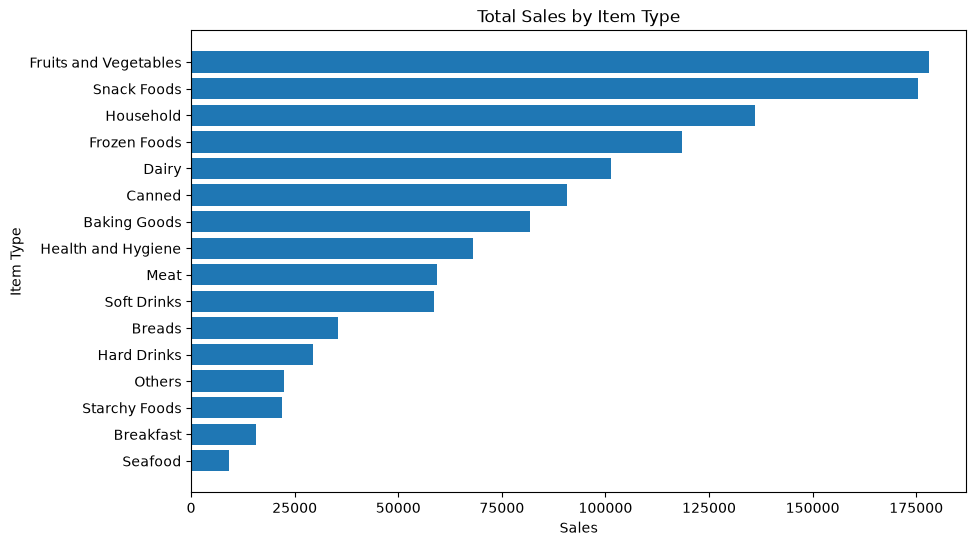

In [41]:
sales_by_item = df.groupby('item_type')['sales'].sum().sort_values()

plt.figure(figsize=(10,6))
plt.barh(sales_by_item.index, sales_by_item.values)
plt.title("Total Sales by Item Type")
plt.xlabel("Sales")
plt.ylabel("Item Type")
plt.show()

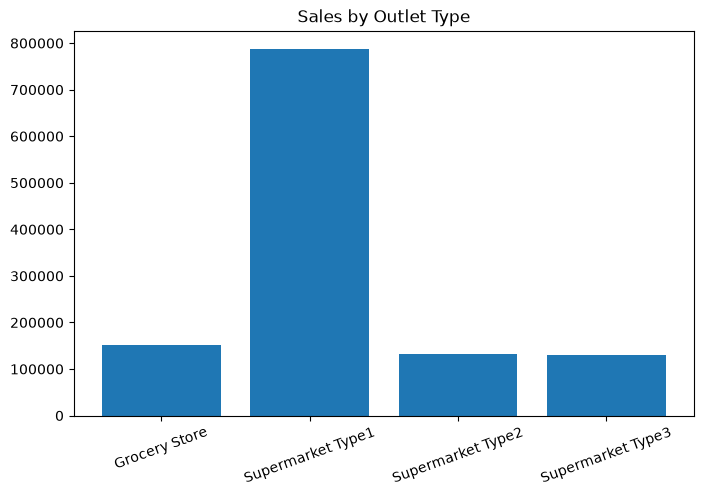

In [43]:
sales_outlet = df.groupby('outlet_type')['sales'].sum()

plt.figure(figsize=(8,5))
plt.bar(sales_outlet.index, sales_outlet.values)
plt.title("Sales by Outlet Type")
plt.xticks(rotation=20)
plt.show()

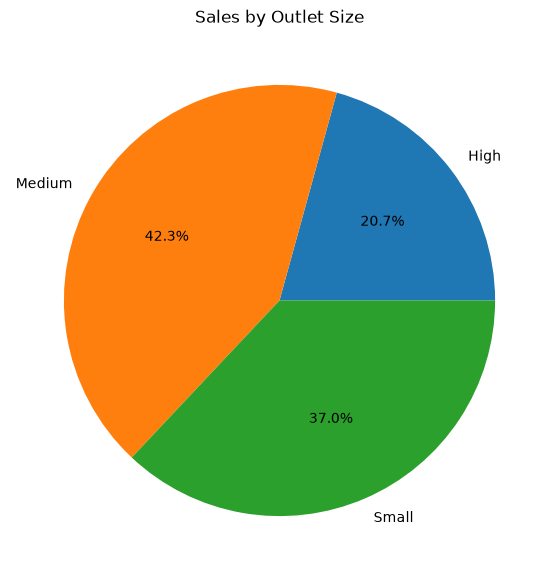

In [44]:
sales_size = df.groupby('outlet_size')['sales'].sum()

plt.figure(figsize=(7,7))
plt.pie(
    sales_size,
    labels=sales_size.index,
    autopct='%1.1f%%'
)
plt.title("Sales by Outlet Size")
plt.show()

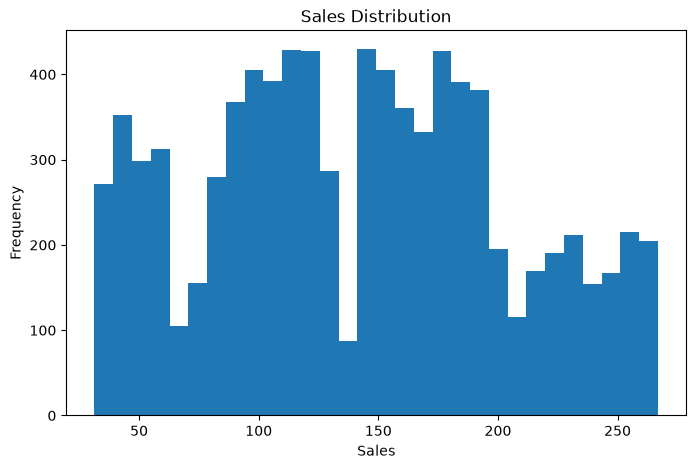

In [45]:
plt.figure(figsize=(8,5))
plt.hist(df['sales'], bins=30)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

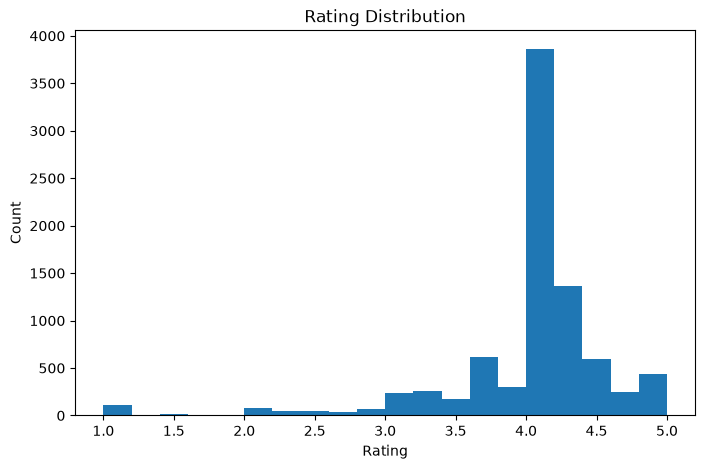

In [46]:
plt.figure(figsize=(8,5))
plt.hist(df['rating'], bins=20)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

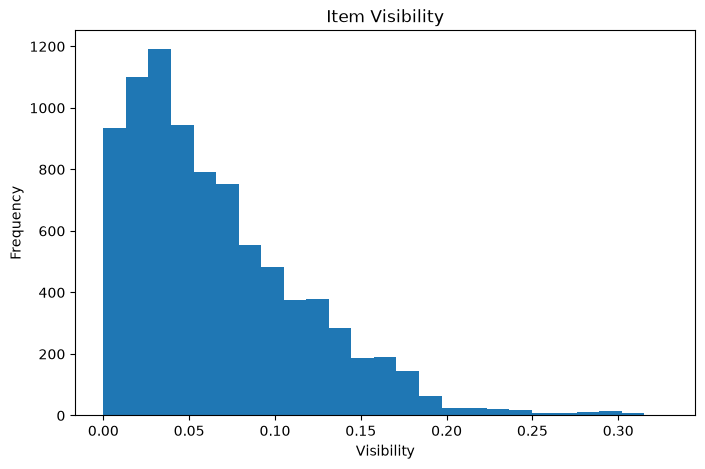

In [47]:
plt.figure(figsize=(8,5))
plt.hist(df['item_visibility'], bins=25)
plt.title("Item Visibility")
plt.xlabel("Visibility")
plt.ylabel("Frequency")
plt.show()

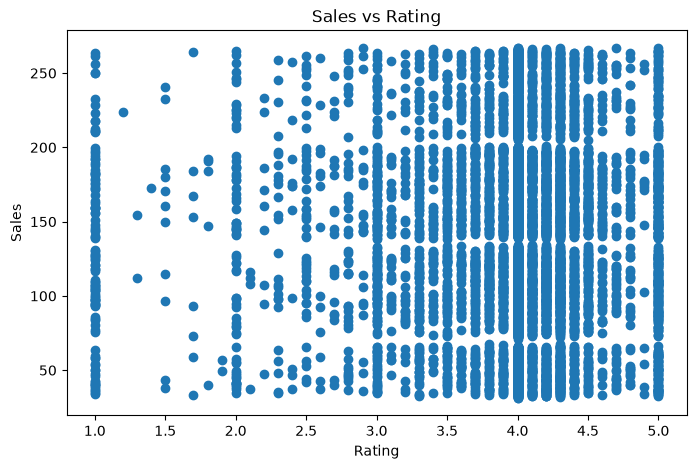

In [48]:
plt.figure(figsize=(8,5))
plt.scatter(df['rating'], df['sales'])
plt.title("Sales vs Rating")
plt.xlabel("Rating")
plt.ylabel("Sales")
plt.show()

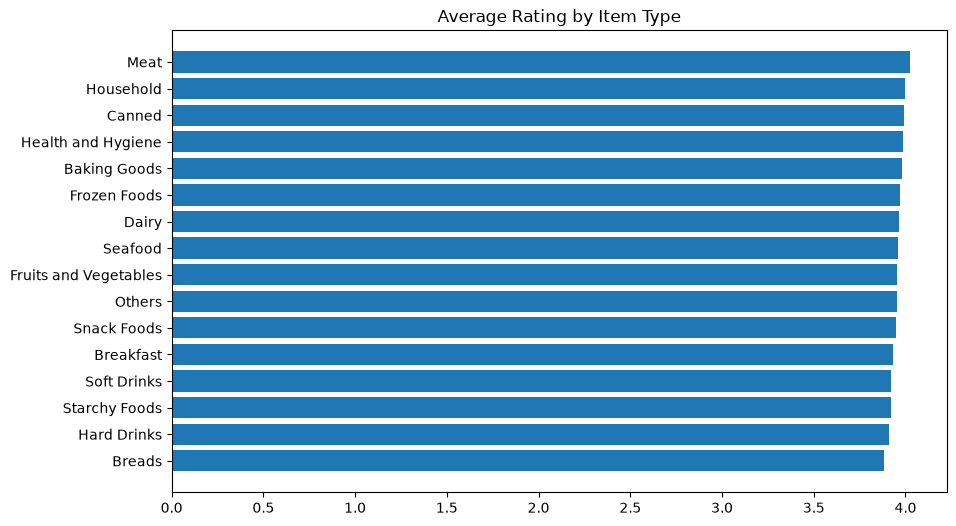

In [49]:
rating = df.groupby('item_type')['rating'].mean().sort_values()

plt.figure(figsize=(10,6))
plt.barh(rating.index, rating.values)
plt.title("Average Rating by Item Type")
plt.show()

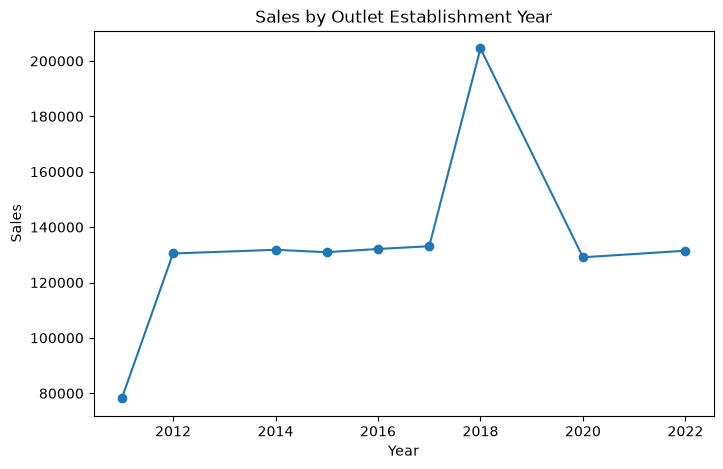

In [50]:
year_sales = df.groupby('outlet_establishment_year')['sales'].sum()

plt.figure(figsize=(8,5))
plt.plot(year_sales.index, year_sales.values, marker='o')
plt.title("Sales by Outlet Establishment Year")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.show()

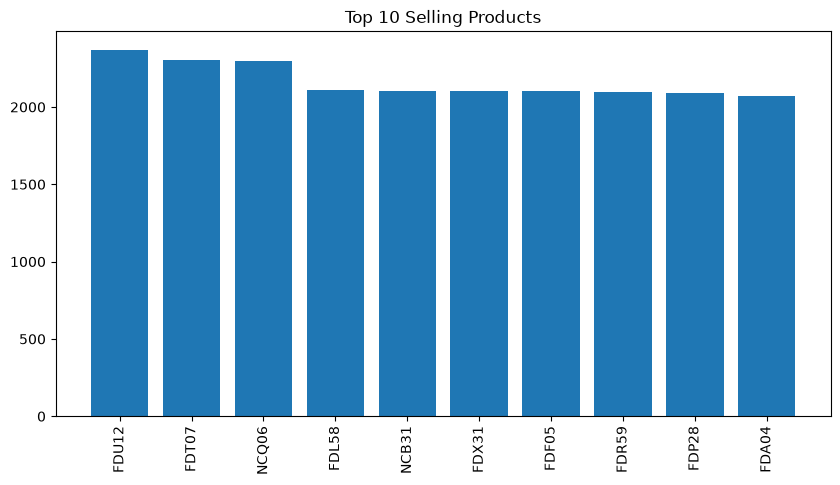

In [51]:
top10 = (
    df.groupby('item_identifier')['sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
plt.bar(top10.index, top10.values)
plt.xticks(rotation=90)
plt.title("Top 10 Selling Products")
plt.show()